In [19]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

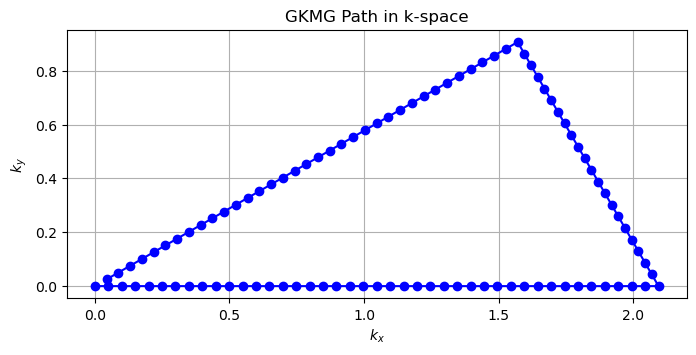

In [ ]:
L=1

k_res = 100
# Define the GKMG sweep in reciprocal space
kx1 = np.linspace(0, 2*np.pi/3/L, int(k_res/(3+np.sqrt(3))*2), endpoint=False)
ky1 = np.linspace(0, 0, int(k_res/(3+np.sqrt(3))*2), endpoint=False)

kx2 = np.linspace(2*np.pi/3/L, 3/2*np.pi/3/L, int(k_res/(3+np.sqrt(3))), endpoint=False)
ky2 = np.linspace(0, np.pi/np.sqrt(3)/2/L, int(k_res/(3+np.sqrt(3))), endpoint=False)

kx3 = np.linspace(3/2*np.pi/3/L, 0, int(k_res/(3+np.sqrt(3))*np.sqrt(3)), endpoint=False)
ky3 = np.linspace(np.pi/np.sqrt(3)/2/L, 0, int(k_res/(3+np.sqrt(3))*np.sqrt(3)), endpoint=False)

kx_sweep = np.concatenate([kx1, kx2, kx3])
ky_sweep = np.concatenate([ky1, ky2, ky3])

# Plot the k-space path, set axis aspect to equal
plt.figure(figsize=(8, 6))
plt.plot(kx_sweep, ky_sweep, marker='o', linestyle='-', color='b')
plt.title('GKMG Path in k-space')
plt.xlabel('$k_x$')
plt.ylabel('$k_y$')
plt.grid()
plt.gca().set_aspect('equal', adjustable='box')
plt.show()


In [25]:
bands = np.zeros((len(kx_sweep), 3))  # Placeholder for band energies
t = 1

for i, (kx, ky) in tqdm(enumerate(zip(kx_sweep, ky_sweep))):
    M = -t*np.array([[0, 1+np.exp(-1j*2*kx*L), 1+np.exp(-1j*(kx-np.sqrt(3)*ky)*L)],
                     [1+np.exp(1j*2*kx*L), 0, 1+np.exp(1j*(kx+np.sqrt(3)*ky)*L)],
                     [1+np.exp(1j*(kx-np.sqrt(3)*ky)*L), 1+np.exp(-1j*(kx+np.sqrt(3)*ky)*L), 0]])

    bands[i] = np.linalg.eigvalsh(M)

0it [00:00, ?it/s]

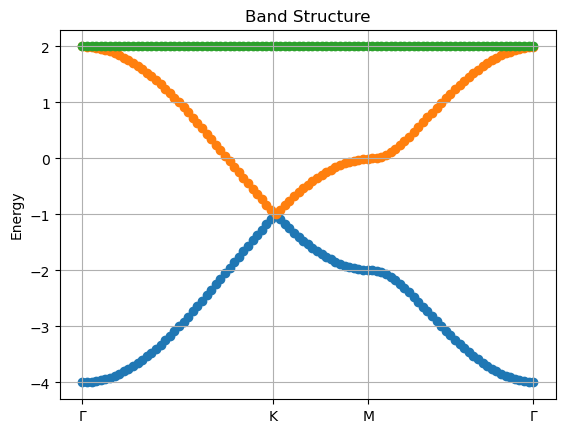

In [ ]:
k_sweep = np.linspace(0, 3+np.sqrt(3), len(kx_sweep))

plt.scatter(k_sweep, bands[:, 0])
plt.scatter(k_sweep, bands[:, 1])
plt.scatter(k_sweep, bands[:, 2])
plt.title('Band Structure')
plt.xticks([0, 2, 3, 3+np.sqrt(3)], ['Γ', 'K', 'M', 'Γ'])
plt.xlabel('')
plt.ylabel('Energy')
plt.grid()
plt.show()